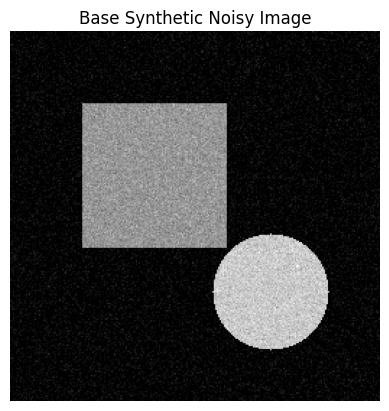

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import filters, feature
import time

# Generate a synthetic image (256x256) with a circle and a square
image = np.zeros((256, 256), dtype=np.uint8)
# Add a square (intensity 150)
image[50:150, 50:150] = 150
# Add a circle (intensity 200)
yy, xx = np.ogrid[:256, :256]
mask_circle = (xx - 180)**2 + (yy - 180)**2 <= 40**2
image[mask_circle] = 200

# Add mild Gaussian noise
np.random.seed(42)
noise = np.random.normal(0, 15, image.shape)
noisy_image = np.clip(image + noise, 0, 255).astype(np.uint8)

plt.imshow(noisy_image, cmap='gray')
plt.title("Base Synthetic Noisy Image")
plt.axis('off')
plt.show()

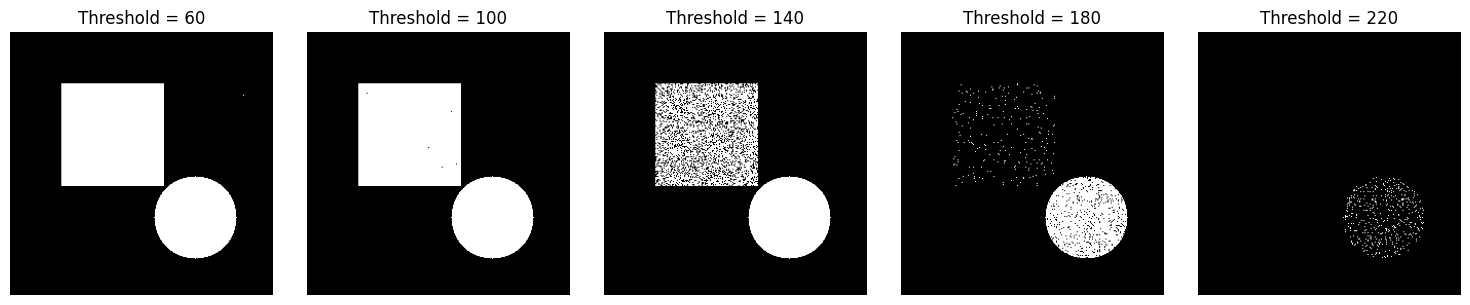


--- Observations ---
* Changes observed: As the threshold increases, fewer pixels make the cut to become part of the foreground (white). Lower thresholds (60, 100) include background noise as foreground. High thresholds (220) start erasing the actual objects.
* Best threshold: T=100 or T=140 provides the best separation here, isolating the shapes cleanly while ignoring the background noise.



In [2]:
# Task 1: Try Different Threshold Values
thresholds = [60, 100, 140, 180, 220]

plt.figure(figsize=(15, 3))
for i, T in enumerate(thresholds):
    # Create binary mask (1 if >= T, else 0)
    mask = (noisy_image >= T).astype(np.uint8)

    plt.subplot(1, len(thresholds), i + 1)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Threshold = {T}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("""
--- Observations ---
* Changes observed: As the threshold increases, fewer pixels make the cut to become part of the foreground (white). Lower thresholds (60, 100) include background noise as foreground. High thresholds (220) start erasing the actual objects.
* Best threshold: T=100 or T=140 provides the best separation here, isolating the shapes cleanly while ignoring the background noise.
""")

In [11]:
# Task 2: Build Your Own Segmentation Function

def my_threshold(img, T):
    rows, cols = img.shape
    # Initialize an empty array of the same size
    output = np.zeros((rows, cols), dtype=np.uint8)

    # Nested loops to check every single pixel
    for i in range(rows):
        for j in range(cols):
            if img[i, j] >= T:
                output[i, j] = 1
            else:
                output[i, j] = 0

    return output

# Compare speed and result
start_time = time.time()
custom_mask = my_threshold(noisy_image, 140)
print(f"Custom Loop Time: {time.time() - start_time:.4f} seconds")

start_time = time.time()
global_mask = (noisy_image >= 140).astype(np.uint8)
print(f"Vectorized Time: {time.time() - start_time:.6f} seconds")

# Verify they are identical
are_identical = np.array_equal(custom_mask, global_mask)
print(f"Are the results identical? {are_identical}")

Custom Loop Time: 0.0245 seconds
Vectorized Time: 0.000951 seconds
Are the results identical? True


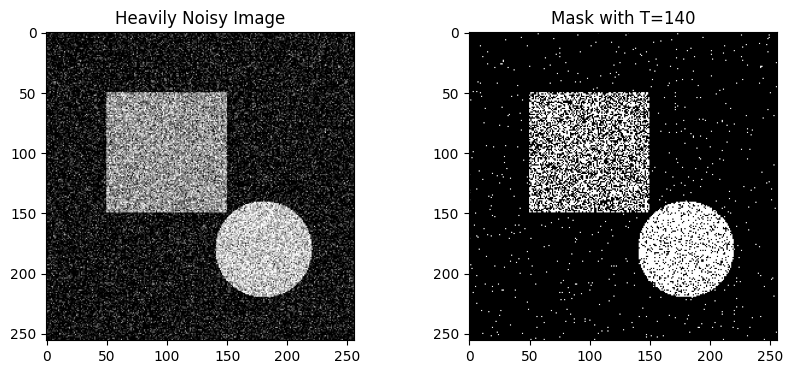


--- Answers to Questions ---
1. What happens to the mask?: The mask becomes highly fragmented ("salt and pepper" effect). Background pixels randomly cross the threshold, and object pixels randomly fall below it.
2. Does the same threshold still work?: No. The static threshold is completely ineffective at cleanly separating the objects due to the variance of the noise.
3. What could you do to improve the result?: We must smooth/blur the image FIRST to reduce the noise variance before thresholding. Applying a Gaussian Blur or Median Filter prior to the threshold step would fix this.



In [5]:
# Task 3: Noise Challenge

# Increase noise significantly
heavy_noise = np.random.normal(0, 60, image.shape) # Standard deviation increased to 60
heavy_noisy_image = np.clip(image + heavy_noise, 0, 255).astype(np.uint8)

mask_heavy = (heavy_noisy_image >= 140).astype(np.uint8)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(heavy_noisy_image, cmap='gray')
plt.title("Heavily Noisy Image")

plt.subplot(1, 2, 2)
plt.imshow(mask_heavy, cmap='gray')
plt.title("Mask with T=140")
plt.show()

print("""
--- Answers to Questions ---
1. What happens to the mask?: The mask becomes highly fragmented ("salt and pepper" effect). Background pixels randomly cross the threshold, and object pixels randomly fall below it.
2. Does the same threshold still work?: No. The static threshold is completely ineffective at cleanly separating the objects due to the variance of the noise.
3. What could you do to improve the result?: We must smooth/blur the image FIRST to reduce the noise variance before thresholding. Applying a Gaussian Blur or Median Filter prior to the threshold step would fix this.
""")

Otsu's Automatically Calculated Threshold: 67.00


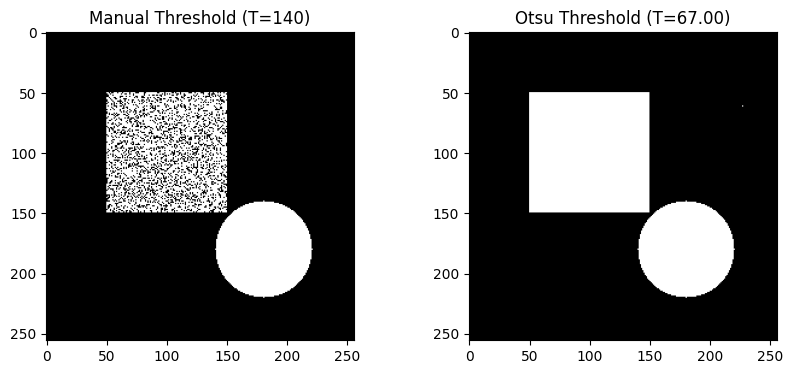

In [6]:
# Challenge 1: Automatic Threshold Selection
from skimage.filters import threshold_otsu

# Compute Otsu's threshold
best_otsu_T = threshold_otsu(noisy_image)
otsu_mask = (noisy_image >= best_otsu_T).astype(np.uint8)

print(f"Otsu's Automatically Calculated Threshold: {best_otsu_T:.2f}")

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(noisy_image >= 140, cmap='gray') # Manual
plt.title("Manual Threshold (T=140)")

plt.subplot(1, 2, 2)
plt.imshow(otsu_mask, cmap='gray')
plt.title(f"Otsu Threshold (T={best_otsu_T:.2f})")
plt.show()

In [7]:
# Challenge 2: Count the Number of White Pixels

# Using the mask generated from Otsu's method
foreground_pixels = np.sum(otsu_mask == 1)
total_pixels = otsu_mask.size
percentage = (foreground_pixels / total_pixels) * 100

print(f"Total image pixels: {total_pixels}")
print(f"Foreground (white) pixels: {foreground_pixels}")
print(f"Percentage of image selected: {percentage:.2f}%")

Total image pixels: 65536
Foreground (white) pixels: 15026
Percentage of image selected: 22.93%


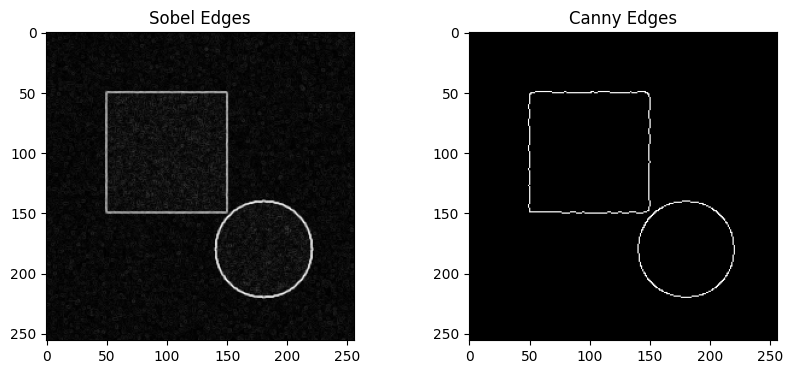


--- Answers to Questions ---
* Which method gives cleaner edges?: Canny gives much cleaner, thinner, and more connected edges.
* Which one is more sensitive to noise?: Sobel is highly sensitive to noise. It calculates raw gradients, so every noisy pixel spike registers as an "edge". Canny is more robust because it has a built-in Gaussian smoothing step (controlled by the sigma parameter) and uses hysteresis thresholding to link strong edges.



In [8]:
# Challenge 3: Edge Detection Comparison
from skimage.filters import sobel
from skimage.feature import canny

# Apply Sobel
edges_sobel = sobel(noisy_image)

# Apply Canny (requires sigma for internal Gaussian blurring)
edges_canny = canny(noisy_image, sigma=2.0)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(edges_sobel, cmap='gray')
plt.title("Sobel Edges")

plt.subplot(1, 2, 2)
plt.imshow(edges_canny, cmap='gray')
plt.title("Canny Edges")
plt.show()

print("""
--- Answers to Questions ---
* Which method gives cleaner edges?: Canny gives much cleaner, thinner, and more connected edges.
* Which one is more sensitive to noise?: Sobel is highly sensitive to noise. It calculates raw gradients, so every noisy pixel spike registers as an "edge". Canny is more robust because it has a built-in Gaussian smoothing step (controlled by the sigma parameter) and uses hysteresis thresholding to link strong edges.
""")

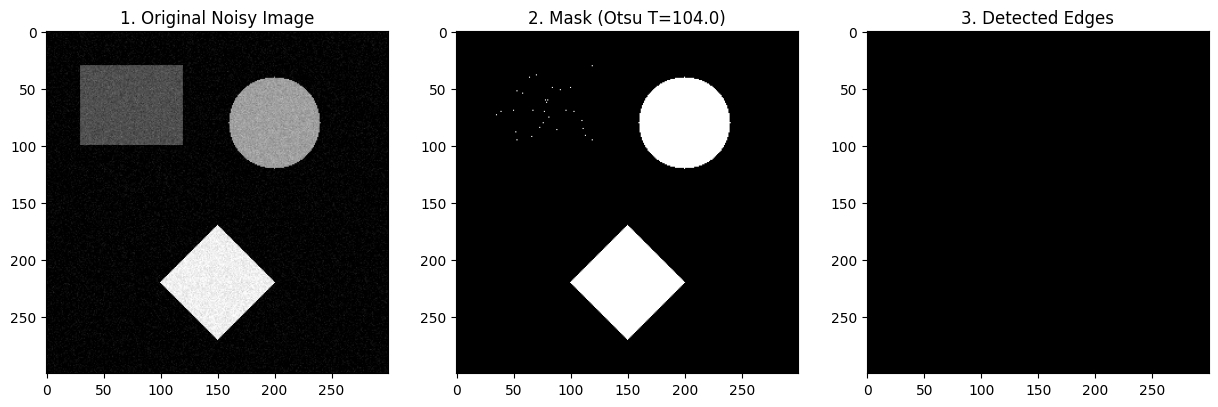


--- Mini Project Observations ---
* Pipeline Effectiveness: Using Otsu's method successfully found a middle-ground threshold to separate all three distinct objects (intensities 80, 160, 240) from the black background (0), despite the noise.
* Edge Detection: Applying Canny directly to the generated binary mask rather than the raw noisy image results in perfectly crisp, 1-pixel-thick boundaries without any noise artifacts. 



In [9]:
# Final Mini Project: Pipeline on a Synthetic Image with 3 objects

# 1. Create your own synthetic image with at least three objects and different intensity values
proj_img = np.zeros((300, 300), dtype=np.uint8)

# Object 1: Dim Rectangle
proj_img[30:100, 30:120] = 80
# Object 2: Medium Intensity Circle
yy, xx = np.ogrid[:300, :300]
mask_c2 = (xx - 200)**2 + (yy - 80)**2 <= 40**2
proj_img[mask_c2] = 160
# Object 3: Bright Diamond (using math trick)
mask_d3 = np.abs(xx - 150) + np.abs(yy - 220) <= 50
proj_img[mask_d3] = 240

# Add noise to make it realistic
proj_noisy = np.clip(proj_img + np.random.normal(0, 10, proj_img.shape), 0, 255).astype(np.uint8)

# 2. Apply thresholding & Generate mask
T_proj = threshold_otsu(proj_noisy)
proj_mask = (proj_noisy > T_proj).astype(np.uint8)

# 3. Detect edges (using Canny on the mask to get crisp outlines)
proj_edges = canny(proj_mask)

# Plot the 3 required figures
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(proj_noisy, cmap='gray')
plt.title("1. Original Noisy Image")

plt.subplot(1, 3, 2)
plt.imshow(proj_mask, cmap='gray')
plt.title(f"2. Mask (Otsu T={T_proj:.1f})")

plt.subplot(1, 3, 3)
plt.imshow(proj_edges, cmap='gray')
plt.title("3. Detected Edges")

# 4. Save the result
plt.savefig("mini_project_pipeline.png", bbox_inches='tight')
plt.show()

print("""
--- Mini Project Observations ---
* Pipeline Effectiveness: Using Otsu's method successfully found a middle-ground threshold to separate all three distinct objects (intensities 80, 160, 240) from the black background (0), despite the noise.
* Edge Detection: Applying Canny directly to the generated binary mask rather than the raw noisy image results in perfectly crisp, 1-pixel-thick boundaries without any noise artifacts.
""")